In [ ]:
# ── Cell 1: environment ──────────────────────────────────────────────────────
!pip -q install ultralytics pycocotools imagehash albumentations fiftyone

from google.colab import drive
drive.mount('/content/drive')

import os, sys, json, re, glob, random, shutil, hashlib
from pathlib import Path
import numpy as np, cv2

# Keep RAW zips on Drive, work on local disk (10-50x faster than Drive I/O)
DRIVE = Path('/content/drive/MyDrive/nirmalsagar')
ROOT  = Path('/content/nirmalsagar')
RAW   = ROOT/'data/raw'
OUT   = ROOT/'data/yolo'
CFG   = ROOT/'configs'
PAPER = ROOT/'paper'
for p in [RAW, OUT/'images', OUT/'labels', CFG, PAPER, ROOT/'splits']:
    p.mkdir(parents=True, exist_ok=True)

# Unzip from Drive -> local. Adjust the zip names to whatever you uploaded.
for z in ['trashcan.zip', 'seaclear.zip', 'jamstec.zip']:
    src = DRIVE/'raw'/z
    if src.exists() and not (RAW/z.replace('.zip','')).exists():
        !unzip -q "{src}" -d "{RAW}/{z.replace('.zip','')}"

SEED = 0
random.seed(SEED); np.random.seed(SEED)
print('\n'.join(str(p) for p in RAW.glob('*')))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 8.1 MB/s eta 0

In [ ]:
!pip install -q --force-reinstall --no-deps "pillow==11.3.0"
!pip install -q "ultralytics>=8.3.0"
import PIL; print(PIL.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 93.4 MB/s eta 0:00:00
11.3.0


In [ ]:
# ── Cell 0R: after restart, re-establish paths only ──────────────────────────
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

ROOT   = Path('/content/nirmalsagar')
RAW    = ROOT/'data/raw'
OUT    = ROOT/'data/yolo'
CFG    = ROOT/'configs'
PAPER  = ROOT/'paper'
SPLITS = ROOT/'splits'
DRIVE  = Path('/content/drive/MyDrive/nirmalsagar')
SEED   = 0

# sanity: the pipeline's output must have survived
import itertools
print('configs :', len(list(CFG.glob('*.yaml'))), 'yaml')
print('splits  :', len(list(SPLITS.glob('*.txt'))), 'txt')
print('labels  :', sum(1 for _ in (OUT/'labels/core3').rglob('*.txt')))
print('images  :', sum(1 for _ in (OUT/'images/core3').rglob('*')))
p = next((OUT/'images/core3').rglob('*.jpg'))
print('symlink OK :', p.resolve().exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
configs : 11 yaml
splits  : 12 txt
labels  : 20739
images  : 20742
symlink OK : True


In [ ]:
# ── Cell 1b: paths (corrected for the double-nesting from the zips) ──────────
import os
from pathlib import Path
from collections import Counter

RAW = Path('/content/nirmalsagar/data/raw')   # re-declared so this cell stands alone

TRASHCAN_ROOT = RAW/'trashcan/trashcan/material_version'
TRASHCAN_JSONS = {
    'train': TRASHCAN_ROOT/'instances_train_trashcan.json',
    'val':   TRASHCAN_ROOT/'instances_val_trashcan.json',
}
TRASHCAN_IMG_DIRS = {
    'train': TRASHCAN_ROOT/'train',
    'val':   TRASHCAN_ROOT/'val',
}

SEACLEAR_ROOT = RAW/'seaclear/seaclear'
SEACLEAR_JSON = SEACLEAR_ROOT/'dataset.json'

JAMSTEC_ROOT = RAW/'jamstec/jamstec'
JAMSTEC_JSON = JAMSTEC_ROOT/'coco.json'
JAMSTEC_IMGS = JAMSTEC_ROOT/'images'

# ---- verify ------------------------------------------------------------------
for p in [*TRASHCAN_JSONS.values(), SEACLEAR_JSON, JAMSTEC_JSON]:
    assert p.exists(), f'MISSING FILE: {p}'
for p in [*TRASHCAN_IMG_DIRS.values(), SEACLEAR_ROOT, JAMSTEC_IMGS]:
    assert p.is_dir(), f'MISSING DIR: {p}'
print('all annotation files found ✓\n')

IMG_EXTS = ('.jpg', '.jpeg', '.png')

for name, d in [('trashcan/train', TRASHCAN_IMG_DIRS['train']),
                ('trashcan/val',   TRASHCAN_IMG_DIRS['val']),
                ('jamstec/images', JAMSTEC_IMGS)]:
    n = len([f for f in os.listdir(d) if f.lower().endswith(IMG_EXTS)])
    print(f'{name:20s} {n:6d} images')

sc = [p for p in SEACLEAR_ROOT.rglob('*') if p.suffix.lower() in IMG_EXTS]
print(f'{"seaclear (all sites)":20s} {len(sc):6d} images')
for site in sorted(p.name for p in SEACLEAR_ROOT.iterdir() if p.is_dir()):
    cams = sorted(p.name for p in (SEACLEAR_ROOT/site).iterdir() if p.is_dir())
    n = len([p for p in (SEACLEAR_ROOT/site).rglob('*') if p.suffix.lower() in IMG_EXTS])
    print(f'   {site:12s} {n:5d}   cameras: {cams}')

# ---- file-extension census (diagnostic - tells Cell 3 what to glob for) -----
print('\nextensions present in seaclear:',
      dict(Counter(p.suffix for p in SEACLEAR_ROOT.rglob('*.*'))))

all annotation files found ✓

trashcan/train         6008 images
trashcan/val           1204 images
jamstec/images        11810 images
seaclear (all sites)   8610 images
   Bistrina      3652   cameras: ['Bluerobotics HD', 'Paralenz Vaquita Gen 2', 'SIP-E323CV']
   Jakljan        306   cameras: ['Bluerobotics HD', 'Paralenz Vaquita']
   Lokrum         972   cameras: ['Bluerobotics HD', 'Paralenz Vaquita Gen 2', 'SIP-E323CV']
   Marseille     3441   cameras: ['SIP-E323CV']
   Slano          239   cameras: ['Bluerobotics HD', 'Paralenz Vaquita']

extensions present in seaclear: {'.json': 1, '.jpg': 8610}


In [ ]:
# ── Cell 2: taxonomy (verbatim category strings, verified against your JSONs) ─
import json

CORE3     = ['plastic', 'metal', 'other_debris']
EXTENDED6 = ['plastic', 'metal', 'other_debris', 'fishing_gear', 'rubber', 'biological']

TRASHCAN_MAP = {
    'trash_plastic': 'plastic',
    'trash_metal': 'metal',
    'trash_fishing_gear': 'fishing_gear',
    'trash_rubber': 'rubber',
    'trash_etc': 'other_debris', 'trash_fabric': 'other_debris',
    'trash_paper': 'other_debris', 'trash_wood': 'other_debris',
    'plant': 'biological', 'animal_fish': 'biological', 'animal_starfish': 'biological',
    'animal_shells': 'biological', 'animal_crab': 'biological',
    'animal_eel': 'biological', 'animal_etc': 'biological',
    'rov': None,                                   # ignore: platform hardware
}

SEACLEAR_MAP = {
    # plastic
    'bottle_plastic': 'plastic', 'bag_plastic': 'plastic', 'container_plastic': 'plastic',
    'cup_plastic': 'plastic', 'lid_plastic': 'plastic', 'pipe_plastic': 'plastic',
    'tarp_plastic': 'plastic', 'sanitaries_plastic': 'plastic',
    'snack_wrapper_plastic': 'plastic',
    # metal
    'can_metal': 'metal', 'cable_metal': 'metal', 'wreckage_metal': 'metal',
    'container_middle_size_metal': 'metal',
    # fishing gear -- FUNCTION beats material naming, to match trash_fishing_gear
    'net_plastic': 'fishing_gear', 'rope_plastic': 'fishing_gear', 'rope_fiber': 'fishing_gear',
    # rubber
    'tire_rubber': 'rubber', 'boot_rubber': 'rubber',
    # other debris
    'tube_cement': 'other_debris', 'brick_clay': 'other_debris',
    'bottle_glass': 'other_debris', 'jar_glass': 'other_debris',
    'cup_ceramic': 'other_debris', 'clothing_fiber': 'other_debris',
    'cardboard_paper': 'other_debris', 'snack_wrapper_paper': 'other_debris',
    'branch_wood': 'other_debris', 'furniture_wood': 'other_debris',
    # biological
    'plant': 'biological', 'animal_urchin': 'biological', 'animal_etc': 'biological',
    'animal_sponge': 'biological', 'animal_fish': 'biological',
    'animal_shells': 'biological', 'animal_starfish': 'biological',
    # ignore
    'rov_cable': None, 'rov_tortuga': None, 'rov_vehicle_leg': None,
    'rov_bluerov': None, 'unknown_instance': None,
}

JAMSTEC_MAP = {
    'plastic-film': 'plastic', 'plastic-bottle': 'plastic',
    'beverage-can': 'metal', 'other-metal': 'metal',
    'others': 'other_debris',
}

# JAMSTEC never annotates these. Core-3 sidesteps the problem entirely, which is
# precisely why Core-3 is the class set used for every cross-domain number.
ABSENT = {'trashcan': set(), 'seaclear': set(),
          'jamstec': {'fishing_gear', 'rubber', 'biological'}}

def assert_coverage(json_path, mapping, name):
    cats = {c['name'] for c in json.load(open(json_path))['categories']}
    missing = cats - set(mapping)
    extra   = set(mapping) - cats
    assert not missing, f'{name}: UNMAPPED (would be silently dropped) -> {sorted(missing)}'
    if extra:
        print(f'   note: {name} mapping has {len(extra)} unused keys -> {sorted(extra)}')
    print(f'{name:10s} all {len(cats)} categories mapped ✓')

assert_coverage(TRASHCAN_JSONS['train'], TRASHCAN_MAP, 'trashcan')
assert_coverage(SEACLEAR_JSON,           SEACLEAR_MAP, 'seaclear')
assert_coverage(JAMSTEC_JSON,            JAMSTEC_MAP,  'jamstec')

trashcan   all 16 categories mapped ✓
seaclear   all 40 categories mapped ✓
jamstec    all 5 categories mapped ✓


In [ ]:
# ── Cell 3: parse the three datasets into one common record format ───────────
import re, random
from collections import defaultdict, Counter
from pathlib import Path

SEED = 0
random.seed(SEED)
IMG_EXTS = ('.jpg', '.jpeg', '.png')

def _load_coco(p):
    j = json.load(open(p))
    cats = {c['id']: c['name'] for c in j['categories']}
    by_img = defaultdict(list)
    for a in j['annotations']:
        by_img[a['image_id']].append(a)
    return j, cats, by_img

def _records(coco, cats, by_img, mapping, domain, img_fn, group_fn, extra_fn=None):
    recs = []
    for im in coco['images']:
        anns = []
        for a in by_img.get(im['id'], []):
            if a.get('iscrowd', 0):
                continue
            raw = cats[a['category_id']]
            if raw not in mapping:
                raise KeyError(f'{domain}: unmapped category {raw!r}')
            cls = mapping[raw]
            if cls is None:                       # ignore region (rov, unknown)
                continue
            anns.append({'cls': cls, 'seg': a.get('segmentation'), 'bbox': a['bbox']})
        r = {'domain': domain,
             'file': str(img_fn(im)),
             'w': im['width'], 'h': im['height'],
             'group_id': group_fn(im),
             'anns': anns,
             'is_bg': len(anns) == 0}
        if extra_fn:
            r.update(extra_fn(im))
        recs.append(r)
    return recs

# ---- TrashCan (material_version) --------------------------------------------
def tc_group(im):
    n = Path(im['file_name']).name
    m = re.match(r'(vid_\d+)', n) or re.match(r'(.+?)_frame', n)
    return m.group(1) if m else n            # worst case: 1 image per group

tc_recs = []
for split, jp in TRASHCAN_JSONS.items():
    coco, cats, by_img = _load_coco(jp)
    d = TRASHCAN_IMG_DIRS[split]
    tc_recs += _records(coco, cats, by_img, TRASHCAN_MAP, 'trashcan',
                        img_fn=lambda im, d=d: d/Path(im['file_name']).name,
                        group_fn=tc_group)

# ---- SeaClear: recover site + camera from the physical disk path ------------
disk = {}
for p in SEACLEAR_ROOT.rglob('*'):
    if p.suffix.lower() not in IMG_EXTS:
        continue
    rel = p.relative_to(SEACLEAR_ROOT).parts
    if len(rel) >= 2:
        disk[p.name] = {'path': p, 'site': rel[0],
                        'camera': rel[1] if len(rel) > 2 else 'unknown'}
print('seaclear images found on disk:', len(disk))

coco, cats, by_img = _load_coco(SEACLEAR_JSON)
missing = [im['file_name'] for im in coco['images']
           if Path(im['file_name']).name not in disk]
print('seaclear json entries with NO file on disk:', len(missing), missing[:5])
assert not missing, 'fix the disk index before continuing -- LOSO depends on it'

sc_recs = _records(coco, cats, by_img, SEACLEAR_MAP, 'seaclear',
                   img_fn=lambda im: disk[Path(im['file_name']).name]['path'],
                   group_fn=lambda im: disk[Path(im['file_name']).name]['site'],
                   extra_fn=lambda im: {
                       'site':   disk[Path(im['file_name']).name]['site'],
                       'camera': disk[Path(im['file_name']).name]['camera']})

# ---- JAMSTEC: dive id from the filename prefix ------------------------------
def dive_id(fn):
    m = re.match(r'([A-Za-z0-9]{6})', fn)
    return m.group(1) if m else 'unknown'

coco, cats, by_img = _load_coco(JAMSTEC_JSON)
jm_all = _records(coco, cats, by_img, JAMSTEC_MAP, 'jamstec',
                  img_fn=lambda im: JAMSTEC_IMGS/Path(im['file_name']).name,
                  group_fn=lambda im: dive_id(Path(im['file_name']).name),
                  extra_fn=lambda im: {'dive': dive_id(Path(im['file_name']).name)})

# ---- THE THREE NUMBERS THAT DECIDE THE PROTOCOL -----------------------------
pos = [r for r in jm_all if not r['is_bg']]
bg  = [r for r in jm_all if r['is_bg']]
print(f'\njamstec: {len(pos)} annotated, {len(bg)} background, {len(jm_all)} total')
print('DISTINCT DIVES among annotated images:', len({r["dive"] for r in pos}))
print('top dives:', Counter(r['dive'] for r in pos).most_common(10))

print('\nseaclear sites:', Counter(r['site'] for r in sc_recs))
print('trashcan video groups:', len({r['group_id'] for r in tc_recs}))

seaclear images found on disk: 8610
seaclear json entries with NO file on disk: 0 []

jamstec: 3978 annotated, 7832 background, 11810 total
DISTINCT DIVES among annotated images: 618
top dives: [('6K1744', 492), ('KAIKO0', 321), ('6K1741', 196), ('6K1695', 135), ('6K1867', 123), ('6K1662', 111), ('HPD224', 106), ('KMROV0', 95), ('6K1739', 72), ('6K1667', 67)]

seaclear sites: Counter({'Bistrina': 3652, 'Marseille': 3441, 'Lokrum': 972, 'Jakljan': 306, 'Slano': 239})
trashcan video groups: 312


In [ ]:
# ── Cell 3b: subsample JAMSTEC backgrounds to 12%, assemble the master dict ──
rng = random.Random(SEED)
jm_recs = pos + rng.sample(bg, int(0.12 * len(bg)))
print(f'jamstec kept: {len(jm_recs)}  ({len(pos)} positive + {len(jm_recs)-len(pos)} negative)')

ALL = {'trashcan': tc_recs, 'seaclear': sc_recs, 'jamstec': jm_recs}
print(f'\n{"domain":10s} {"images":>7s} {"instances":>10s} {"groups":>7s}  classes')
for d, recs in ALL.items():
    inst = Counter(a['cls'] for r in recs for a in r['anns'])
    print(f'{d:10s} {len(recs):7d} {sum(inst.values()):10d} '
          f'{len({r["group_id"] for r in recs}):7d}  {dict(inst)}')

jamstec kept: 4917  (3978 positive + 939 negative)

domain      images  instances  groups  classes
trashcan      7212       9019     312  {'biological': 2805, 'plastic': 1864, 'other_debris': 2886, 'metal': 1126, 'fishing_gear': 196, 'rubber': 142}
seaclear      8610      29397       5  {'metal': 1604, 'plastic': 2989, 'other_debris': 5290, 'biological': 13790, 'fishing_gear': 3007, 'rubber': 2717}
jamstec       4917       4884    1027  {'plastic': 3134, 'other_debris': 1061, 'metal': 689}


In [ ]:
# ── Cell 3c: fix SeaClear grouping (5 site groups is far too coarse) ─────────
BLOCK = 50   # consecutive frames per group; a "pseudo-sequence"

def frame_num(path):
    m = re.search(r'(\d+)', Path(path).stem)
    return int(m.group(1)) if m else 0

by_cam = defaultdict(list)
for r in sc_recs:
    by_cam[(r['site'], r['camera'])].append(r)

for (site, cam), recs in by_cam.items():
    recs.sort(key=lambda r: frame_num(r['file']))
    for i, r in enumerate(recs):
        r['group_id'] = f'{site}|{cam}|b{i // BLOCK:04d}'

print('seaclear groups now:', len({r["group_id"] for r in sc_recs}))
print('per site:', Counter(r['group_id'].split('|')[0] for r in sc_recs))
ALL['seaclear'] = sc_recs

seaclear groups now: 177
per site: Counter({'Bistrina': 3652, 'Marseille': 3441, 'Lokrum': 972, 'Jakljan': 306, 'Slano': 239})


In [ ]:
# ── Cell 0: canonical paths. Re-run this after any runtime restart. ──────────
from pathlib import Path
from collections import defaultdict, Counter
from tqdm.auto import tqdm
import json, os, re, random
import numpy as np, cv2

ROOT   = Path('/content/nirmalsagar')
RAW    = ROOT/'data/raw'
OUT    = ROOT/'data/yolo'
CFG    = ROOT/'configs'
PAPER  = ROOT/'paper'
SPLITS = ROOT/'splits'
DRIVE  = Path('/content/drive/MyDrive/nirmalsagar')
for p in [OUT/'images', OUT/'labels', CFG, PAPER, SPLITS]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 0
random.seed(SEED); np.random.seed(SEED)
print('paths ready:', ROOT)

paths ready: /content/nirmalsagar


In [ ]:
# ── Cell 4: COCO polygons -> YOLO-seg, images symlinked (saves ~3 GB) ────────
from pycocotools import mask as maskutils
from tqdm.auto import tqdm
import numpy as np, cv2, os

def seg_to_polygon(seg, bbox, w, h):
    """Largest polygon, normalised. Falls back to the bbox if seg is unusable."""
    poly = None
    if isinstance(seg, list) and seg:
        cand = [s for s in seg if isinstance(s, list) and len(s) >= 6]
        if cand:
            poly = max(cand, key=len)
    elif isinstance(seg, dict):                      # RLE
        try:
            m = maskutils.decode(maskutils.frPyObjects(seg, h, w))
            m = m[..., 0] if m.ndim == 3 else m
            cs, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL,
                                     cv2.CHAIN_APPROX_SIMPLE)
            if cs:
                c = cv2.approxPolyDP(max(cs, key=cv2.contourArea), 1.0, True)
                poly = c.reshape(-1, 2).flatten().tolist()
        except Exception:
            poly = None
    if poly is None or len(poly) < 6:
        x, y, bw, bh = bbox
        poly = [x, y, x+bw, y, x+bw, y+bh, x, y+bh]
    p = np.asarray(poly, dtype=np.float32).reshape(-1, 2)
    p[:, 0] = np.clip(p[:, 0] / w, 0, 1)
    p[:, 1] = np.clip(p[:, 1] / h, 0, 1)
    return p.flatten().tolist()

def write_yolo(records, classes, tag):
    names, stats, fallbacks = {c: i for i, c in enumerate(classes)}, Counter(), 0
    for r in tqdm(records, desc=f'writing {tag}'):
        d, stem = r['domain'], f'{r["domain"]}__{Path(r["file"]).stem}'
        img_dir, lbl_dir = OUT/'images'/tag/d, OUT/'labels'/tag/d
        img_dir.mkdir(parents=True, exist_ok=True)
        lbl_dir.mkdir(parents=True, exist_ok=True)

        link = img_dir/f'{stem}.jpg'
        if not link.exists():
            try: os.symlink(Path(r['file']).resolve(), link)
            except FileExistsError: pass

        lines = []
        for a in r['anns']:
            if a['cls'] not in names:
                continue                        # e.g. biological under core3
            if not (isinstance(a['seg'], (list, dict)) and a['seg']):
                fallbacks += 1
            poly = seg_to_polygon(a['seg'], a['bbox'], r['w'], r['h'])
            lines.append(f'{names[a["cls"]]} ' + ' '.join(f'{v:.6f}' for v in poly))
            stats[(d, a['cls'])] += 1
        (lbl_dir/f'{stem}.txt').write_text('\n'.join(lines))   # empty file = negative
        r[f'yolo_{tag}'] = str(link)
    print(f'\n[{tag}] {len(records)} images, {sum(stats.values())} instances, '
          f'{fallbacks} bbox fallbacks')
    for (d, c), n in sorted(stats.items()):
        print(f'   {d:10s} {c:14s} {n}')
    return stats

records_all = tc_recs + sc_recs + jm_recs
core3_stats = write_yolo(records_all, CORE3, 'core3')
ext6_stats  = write_yolo(tc_recs + sc_recs, EXTENDED6, 'ext6')   # JAMSTEC excluded

writing core3:   0%|          | 0/20739 [00:00<?, ?it/s]


[core3] 20739 images, 20643 instances, 0 bbox fallbacks
   jamstec    metal          689
   jamstec    other_debris   1061
   jamstec    plastic        3134
   seaclear   metal          1604
   seaclear   other_debris   5290
   seaclear   plastic        2989
   trashcan   metal          1126
   trashcan   other_debris   2886
   trashcan   plastic        1864


writing ext6:   0%|          | 0/15822 [00:00<?, ?it/s]


[ext6] 15822 images, 38416 instances, 0 bbox fallbacks
   seaclear   biological     13790
   seaclear   fishing_gear   3007
   seaclear   metal          1604
   seaclear   other_debris   5290
   seaclear   plastic        2989
   seaclear   rubber         2717
   trashcan   biological     2805
   trashcan   fishing_gear   196
   trashcan   metal          1126
   trashcan   other_debris   2886
   trashcan   plastic        1864
   trashcan   rubber         142


In [ ]:
# ── Cell 5: cross-dataset perceptual-hash dedup ──────────────────────────────
# TrashCan was cut from JAMSTEC J-EDI footage. Both are ~480x270. If a frame
# lives in both, LODO-1 and LODO-3 are contaminated and every number is wrong.
import imagehash
from PIL import Image

HAM = 5                        # Hamming distance for "near-duplicate"
PAPER = ROOT/'paper'; PAPER.mkdir(parents=True, exist_ok=True)

hashes = {}
for r in tqdm(records_all, desc='hashing'):
    try:
        hashes[r['yolo_core3']] = (imagehash.phash(Image.open(r['file'])), r['domain'])
    except Exception as e:
        print('skip', r['file'], type(e).__name__)

# bucket on a hash prefix so this stays fast instead of O(n^2) over 20k images
buckets = defaultdict(list)
for path, (h, d) in hashes.items():
    buckets[str(h)[:8]].append((path, h, d))

groups, claimed = [], set()
for items in tqdm(buckets.values(), desc='grouping'):
    for i, (p1, h1, d1) in enumerate(items):
        if p1 in claimed:
            continue
        grp = [(p1, d1)]
        for p2, h2, d2 in items[i+1:]:
            if p2 not in claimed and (h1 - h2) <= HAM:
                grp.append((p2, d2)); claimed.add(p2)
        if len(grp) > 1:
            claimed.add(p1); groups.append(grp)

cross = [g for g in groups if len({d for _, d in g}) > 1]
pairs = Counter(tuple(sorted({d for _, d in g})) for g in cross)

print(f'\nnear-duplicate groups (any):   {len(groups)}')
print(f'CROSS-DATASET groups:          {len(cross)}')
for k, v in pairs.items():
    print(f'   {k}: {v}')
print(f'images involved in a dup group: {len(claimed) + len(groups)}')

# force every duplicate group into the SAME split later
dup_group = {}
for gi, g in enumerate(groups):
    for p, _ in g:
        dup_group[p] = f'dup{gi}'

json.dump({'hamming': HAM, 'n_groups': len(groups), 'n_cross': len(cross),
           'pairs': {str(k): v for k, v in pairs.items()}},
          open(PAPER/'dedup_report.json', 'w'), indent=2)
print('\nwrote paper/dedup_report.json')

hashing:   0%|          | 0/20739 [00:00<?, ?it/s]

grouping:   0%|          | 0/15271 [00:00<?, ?it/s]


near-duplicate groups (any):   1828
CROSS-DATASET groups:          84
   ('jamstec', 'trashcan'): 84
images involved in a dup group: 8735

wrote paper/dedup_report.json


In [ ]:
# ── Cell 6: drop cross-dataset twins, then build leak-free splits + configs ──
import yaml

# --- 6a. delete JAMSTEC's copy of each cross-dataset duplicate ---------------
drop = {p for g in cross for p, d in g if d == 'jamstec'}
before = len(jm_recs)
jm_recs = [r for r in jm_recs if r['yolo_core3'] not in drop]
ALL['jamstec'] = jm_recs
records_all = tc_recs + sc_recs + jm_recs
print(f'removed {before - len(jm_recs)} JAMSTEC images duplicated in TrashCan '
      f'-> {len(jm_recs)} remain')

# --- 6b. group-aware splitting ----------------------------------------------
def split_by_group(recs, tag='core3', ratios=(0.70, 0.15, 0.15), seed=SEED):
    """A video/dive/site-block or duplicate group never straddles two splits."""
    key = {}
    for r in recs:
        p = r[f'yolo_{tag}']
        key[p] = dup_group.get(p, f'{r["domain"]}::{r["group_id"]}')
    by_key = defaultdict(list)
    for r in recs:
        by_key[key[r[f'yolo_{tag}']]].append(r)

    ks = sorted(by_key)
    random.Random(seed).shuffle(ks)
    n = len(recs); tr, va, te = [], [], []
    for k in ks:
        if   len(tr) < ratios[0] * n: tr += by_key[k]
        elif len(va) < ratios[1] * n: va += by_key[k]
        else:                         te += by_key[k]
    return tr, va, te, key

def write_list(recs, name, tag='core3'):
    p = SPLITS/f'{name}.txt'
    p.write_text('\n'.join(r[f'yolo_{tag}'] for r in recs))
    return str(p)

per_domain, keymaps = {}, {}
print(f'\n{"domain":10s} {"train":>6s} {"val":>6s} {"test":>6s}')
for d, recs in ALL.items():
    tr, va, te, key = split_by_group(recs)
    keymaps[d] = key
    per_domain[d] = {'train': write_list(tr, f'{d}_train'),
                     'val':   write_list(va, f'{d}_val'),
                     'test':  write_list(te, f'{d}_test')}
    # leakage assertion -- this is the guard that protects every later number
    s = [{key[r['yolo_core3']] for r in x} for x in (tr, va, te)]
    assert not (s[0] & s[1] or s[0] & s[2] or s[1] & s[2]), f'{d}: GROUP LEAK'
    print(f'{d:10s} {len(tr):6d} {len(va):6d} {len(te):6d}')

# --- 6c. LOSO: Marseille held out entirely ----------------------------------
mar = [r for r in sc_recs if r['site'] == 'Marseille']
cro = [r for r in sc_recs if r['site'] != 'Marseille']
ctr, cva, _, _ = split_by_group(cro, ratios=(0.85, 0.15, 0.0))
loso = {'train': write_list(ctr, 'loso_croatia_train'),
        'val':   write_list(cva, 'loso_croatia_val'),
        'test':  write_list(mar, 'loso_marseille_test')}
print(f'{"LOSO":10s} {len(ctr):6d} {len(cva):6d} {len(mar):6d}  (test = Marseille)')

# --- 6d. configs -------------------------------------------------------------
def write_yaml(name, train, val, test, names):
    (CFG/f'{name}.yaml').write_text(yaml.safe_dump(
        {'path': str(ROOT), 'train': train, 'val': val, 'test': test, 'names': names},
        sort_keys=False))

N3 = {i: c for i, c in enumerate(CORE3)}
for d, s in per_domain.items():
    write_yaml(d, s['train'], s['val'], s['test'], N3)

LODO = {'LODO-1': (['seaclear', 'jamstec'],  'trashcan'),
        'LODO-2': (['trashcan', 'jamstec'],  'seaclear'),   # headline
        'LODO-3': (['trashcan', 'seaclear'], 'jamstec')}
for split, (srcs, tgt) in LODO.items():
    write_yaml(f'{split}_source',
               [per_domain[s]['train'] for s in srcs],
               [per_domain[s]['val']   for s in srcs],
               [per_domain[s]['test']  for s in srcs], N3)
    write_yaml(f'{split}_target', per_domain[tgt]['train'],
               per_domain[tgt]['val'], per_domain[tgt]['test'], N3)

write_yaml('joint', [per_domain[d]['train'] for d in ALL],
           [per_domain[d]['val'] for d in ALL],
           [per_domain[d]['test'] for d in ALL], N3)
write_yaml('loso_marseille', loso['train'], loso['val'], loso['test'], N3)

print('\nconfigs written:')
for p in sorted(CFG.glob('*.yaml')):
    print('  ', p.name)

removed 88 JAMSTEC images duplicated in TrashCan -> 4829 remain

domain      train    val   test
trashcan     5061   1117   1034
seaclear     6030   1294   1286
jamstec      3695    725    409
LOSO         4397    772   3441  (test = Marseille)

configs written:
   LODO-1_source.yaml
   LODO-1_target.yaml
   LODO-2_source.yaml
   LODO-2_target.yaml
   LODO-3_source.yaml
   LODO-3_target.yaml
   jamstec.yaml
   joint.yaml
   loso_marseille.yaml
   seaclear.yaml
   trashcan.yaml


In [ ]:
!wc -l /content/nirmalsagar/splits/*.txt
!cat /content/nirmalsagar/configs/LODO-2_source.yaml
!mkdir -p /content/drive/MyDrive/nirmalsagar
!cp -r /content/nirmalsagar/configs /content/nirmalsagar/splits /content/nirmalsagar/paper \
       /content/drive/MyDrive/nirmalsagar/

    408 /content/nirmalsagar/splits/jamstec_test.txt
   3694 /content/nirmalsagar/splits/jamstec_train.txt
    724 /content/nirmalsagar/splits/jamstec_val.txt
   4396 /content/nirmalsagar/splits/loso_croatia_train.txt
    771 /content/nirmalsagar/splits/loso_croatia_val.txt
   3440 /content/nirmalsagar/splits/loso_marseille_test.txt
   1285 /content/nirmalsagar/splits/seaclear_test.txt
   6029 /content/nirmalsagar/splits/seaclear_train.txt
   1293 /content/nirmalsagar/splits/seaclear_val.txt
   1033 /content/nirmalsagar/splits/trashcan_test.txt
   5060 /content/nirmalsagar/splits/trashcan_train.txt
   1116 /content/nirmalsagar/splits/trashcan_val.txt
  29249 total
path: /content/nirmalsagar
train:
- /content/nirmalsagar/splits/trashcan_train.txt
- /content/nirmalsagar/splits/jamstec_train.txt
val:
- /content/nirmalsagar/splits/trashcan_val.txt
- /content/nirmalsagar/splits/jamstec_val.txt
test:
- /content/nirmalsagar/splits/trashcan_test.txt
- /content/nirmalsagar/splits/jamstec_test.t

In [ ]:
# ── Cell 6e: rebalance JAMSTEC so LODO-3's target test set is usable ─────────
RATIOS = {'trashcan': (0.70, 0.15, 0.15),
          'seaclear': (0.70, 0.15, 0.15),
          'jamstec':  (0.60, 0.15, 0.25)}

per_domain = {}
print(f'{"domain":10s} {"train":>6s} {"val":>6s} {"test":>6s}')
for d, recs in ALL.items():
    tr, va, te, key = split_by_group(recs, ratios=RATIOS[d])
    per_domain[d] = {'train': write_list(tr, f'{d}_train'),
                     'val':   write_list(va, f'{d}_val'),
                     'test':  write_list(te, f'{d}_test')}
    s = [{key[r['yolo_core3']] for r in x} for x in (tr, va, te)]
    assert not (s[0] & s[1] or s[0] & s[2] or s[1] & s[2]), f'{d}: GROUP LEAK'
    print(f'{d:10s} {len(tr):6d} {len(va):6d} {len(te):6d}')

for d, s in per_domain.items():
    write_yaml(d, s['train'], s['val'], s['test'], N3)
for split, (srcs, tgt) in LODO.items():
    write_yaml(f'{split}_source',
               [per_domain[s]['train'] for s in srcs],
               [per_domain[s]['val']   for s in srcs],
               [per_domain[s]['test']  for s in srcs], N3)
    write_yaml(f'{split}_target', per_domain[tgt]['train'],
               per_domain[tgt]['val'], per_domain[tgt]['test'], N3)
write_yaml('joint', [per_domain[d]['train'] for d in ALL],
           [per_domain[d]['val'] for d in ALL],
           [per_domain[d]['test'] for d in ALL], N3)
print('\nconfigs rewritten ✓')

domain      train    val   test
trashcan     5061   1117   1034
seaclear     6030   1294   1286
jamstec      2900    795   1134

configs rewritten ✓


  domain   n      B      G     R  B_sd  G_sd  R_sd  G_over_R
trashcan 400 103.15  99.71 83.21 40.51 33.99 31.38      1.20
seaclear 400 141.09 154.42 92.69 15.16 11.67 34.17      1.67
 jamstec 400 112.27 112.46 86.06 36.31 28.63 26.13      1.31


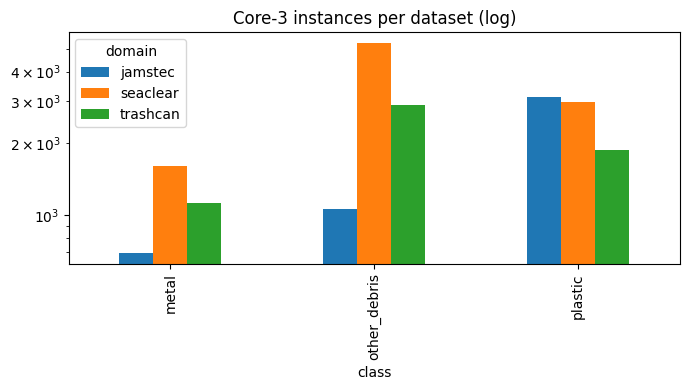

domain        jamstec  seaclear  trashcan
class                                    
metal             689      1604      1126
other_debris     1061      5290      2886
plastic          3134      2989      1864


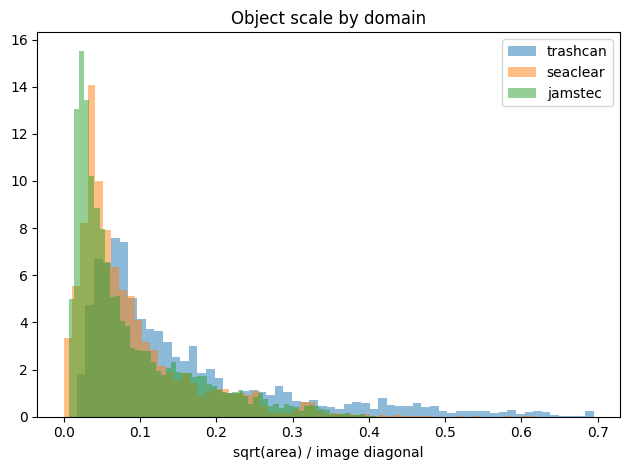


fraction of objects below 3% of image diagonal:
domain
jamstec     0.265
seaclear    0.163
trashcan    0.027


In [ ]:
# ── Cell 7: domain-shift evidence, class balance, object scale ───────────────
import pandas as pd, matplotlib.pyplot as plt

# (a) per-channel colour statistics = quantitative proof the domains differ
rows = []
for d, recs in ALL.items():
    samp = random.Random(0).sample(recs, min(400, len(recs)))
    vals = []
    for r in samp:
        im = cv2.imread(r['file'])
        if im is not None:
            vals.append(im.reshape(-1, 3).mean(0))
    m = np.stack(vals)
    rows.append({'domain': d, 'n': len(m),
                 'B': m[:,0].mean(), 'G': m[:,1].mean(), 'R': m[:,2].mean(),
                 'B_sd': m[:,0].std(), 'G_sd': m[:,1].std(), 'R_sd': m[:,2].std(),
                 'G_over_R': m[:,1].mean()/max(m[:,2].mean(), 1e-6)})
stats_df = pd.DataFrame(rows)
stats_df.to_csv(PAPER/'domain_colour_stats.csv', index=False)
print(stats_df.round(2).to_string(index=False))

# (b) Core-3 class balance per dataset
cb = pd.DataFrame([{'domain': d, 'class': c, 'n': n} for (d, c), n in core3_stats.items()])
piv = cb.pivot(index='class', columns='domain', values='n').fillna(0)
piv.plot(kind='bar', logy=True, figsize=(7, 4), title='Core-3 instances per dataset (log)')
plt.tight_layout(); plt.savefig(PAPER/'class_balance.png', dpi=150); plt.show()
print(piv.astype(int).to_string())

# (c) object scale -> how much of this is a small-object problem
sz = []
for d, recs in ALL.items():
    for r in recs:
        diag = (r['w']**2 + r['h']**2) ** 0.5
        for a in r['anns']:
            if a['cls'] in CORE3:
                sz.append({'domain': d,
                           'rel': (a['bbox'][2]*a['bbox'][3])**0.5 / diag})
sz = pd.DataFrame(sz)
for d in ALL:
    plt.hist(sz[sz.domain == d].rel, bins=60, alpha=0.5, label=d, density=True)
plt.legend(); plt.xlabel('sqrt(area) / image diagonal'); plt.title('Object scale by domain')
plt.tight_layout(); plt.savefig(PAPER/'object_scale.png', dpi=150); plt.show()
print('\nfraction of objects below 3% of image diagonal:')
print(sz.groupby('domain').rel.apply(lambda s: (s < 0.03).mean()).round(3).to_string())

!cp -r /content/nirmalsagar/paper /content/nirmalsagar/configs /content/nirmalsagar/splits \
       /content/drive/MyDrive/nirmalsagar/

In [ ]:
# ── Cell 7b: absolute pixel size, and the COCO small/medium/large breakdown ──
abs_sz = []
for d, recs in ALL.items():
    for r in recs:
        for a in r['anns']:
            if a['cls'] in CORE3:
                area = a['bbox'][2] * a['bbox'][3]
                abs_sz.append({'domain': d, 'px': area ** 0.5, 'area': area})
abs_sz = pd.DataFrame(abs_sz)

def coco_band(a):
    return 'small' if a < 32**2 else ('medium' if a < 96**2 else 'large')
abs_sz['band'] = abs_sz.area.map(coco_band)

print('median object size in PIXELS (sqrt of area):')
print(abs_sz.groupby('domain').px.median().round(1).to_string())
print('\nCOCO size bands (fraction):')
print(abs_sz.groupby('domain').band.value_counts(normalize=True).unstack().round(3).to_string())
abs_sz.to_csv(PAPER/'object_size_absolute.csv', index=False)

median object size in PIXELS (sqrt of area):
domain
jamstec      65.9
seaclear    135.3
trashcan     61.0

COCO size bands (fraction):
band      large  medium  small
domain                        
jamstec   0.282   0.597  0.121
seaclear  0.657   0.283  0.061
trashcan  0.312   0.500  0.188


In [ ]:
# ── Cell 8a: smoke test. Never skip. ─────────────────────────────────────────
from ultralytics import YOLO
YOLO('yolo11n-seg.pt').train(
    data=str(CFG/'trashcan.yaml'), epochs=3, imgsz=320, batch=8, workers=2,
    project=str(ROOT/'runs/smoke'), name='t', exist_ok=True, verbose=True)

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/nirmalsagar/configs/trashcan.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=t, nbs=64, nms=Fal

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f418ec14860>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04

In [ ]:
# ── Cell 8b: TrashCan baseline, checkpointed to Drive ────────────────────────
from ultralytics import YOLO
CKPT = DRIVE/'runs'; CKPT.mkdir(parents=True, exist_ok=True)

_ = YOLO('yolo11s-seg.pt').train(
    data=str(CFG/'trashcan.yaml'),
    epochs=100, imgsz=640, batch=16, workers=2,
    optimizer='SGD', lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005,
    warmup_epochs=3, cos_lr=True, patience=30, amp=True,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=10, translate=0.1, scale=0.5, shear=2.0, fliplr=0.5, flipud=0.1,
    mosaic=1.0, close_mosaic=15, copy_paste=0.3,
    project=str(CKPT), name='yolo11s_trashcan_core3', exist_ok=True,
    save_period=5, seed=SEED, plots=True,
)
print('best:', CKPT/'yolo11s_trashcan_core3/weights/best.pt')

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/nirmalsagar/configs/trashcan.yaml, degrees=10, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_trashcan_

In [ ]:
# ── Cell 9: honest test-split number + the first row of the gap matrix ───────
import pandas as pd
from ultralytics import YOLO

BEST = str(DRIVE/'runs/yolo11s_trashcan_core3/weights/best.pt')
model = YOLO(BEST)

rows = []
for tgt in ['trashcan', 'seaclear', 'jamstec']:
    r = model.val(data=str(CFG/f'{tgt}.yaml'), split='test',
                  imgsz=640, batch=16, workers=2, plots=False, verbose=False,
                  project=str(ROOT/'runs/eval'), name=f'tc_on_{tgt}', exist_ok=True)
    ap = dict(zip([r.names[i] for i in r.box.ap_class_index], r.box.ap50))
    rows.append({'source': 'trashcan', 'target': tgt,
                 'plastic': ap.get('plastic', float('nan')),
                 'metal': ap.get('metal', float('nan')),
                 'other_debris': ap.get('other_debris', float('nan')),
                 'headline(P+M)': (ap.get('plastic', 0) + ap.get('metal', 0)) / 2,
                 'mAP50_all': r.box.map50})

df = pd.DataFrame(rows).round(3)
df.to_csv(PAPER/'gap_row_trashcan.csv', index=False)
print(df.to_string(index=False))

h = df.set_index('target')['headline(P+M)']
print(f"\nΔ to SeaClear : {h['trashcan'] - h['seaclear']:.3f}")
print(f"Δ to JAMSTEC  : {h['trashcan'] - h['jamstec']:.3f}")

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-seg summary (fused): 114 layers, 10,067,977 parameters, 0 gradients, 32.9 GFLOPs
val: Fast image access ✅ (ping: 3.1±0.7 ms, read: 98.1±110.8 MB/s, size: 30.5 KB)
val: Scanning /content/nirmalsagar/data/yolo/labels/core3/trashcan... 1034 images, 266 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1034/1034 868.9it/s 1.2s
val: New cache created: /content/nirmalsagar/data/yolo/labels/core3/trashcan.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 65/65 5.1it/s 12.7s
                   all       1034        897      0.852      0.749      0.798      0.625      0.849      0.746      0.792      0.549
Speed: 0.8ms preprocess, 7.6ms inference, 0.0ms loss, 1.5ms postprocess per image
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 4.4±2

In [ ]:
# ── Cell 10: is the gap appearance, or resolution? ───────────────────────────
import pandas as pd
from ultralytics import YOLO
model = YOLO(str(DRIVE/'runs/yolo11s_trashcan_core3/weights/best.pt'))

rows = []
for tgt in ['trashcan', 'seaclear', 'jamstec']:
    for sz in [640, 960, 1280]:
        r = model.val(data=str(CFG/f'{tgt}.yaml'), split='test', imgsz=sz,
                      batch=8, workers=2, plots=False, verbose=False,
                      project=str(ROOT/'runs/eval'), name=f'sz_{tgt}_{sz}', exist_ok=True)
        ap = dict(zip([r.names[i] for i in r.box.ap_class_index], r.box.ap50))
        rows.append({'target': tgt, 'imgsz': sz,
                     'plastic': ap.get('plastic', 0), 'metal': ap.get('metal', 0),
                     'headline': (ap.get('plastic', 0) + ap.get('metal', 0)) / 2})

sweep = pd.DataFrame(rows).round(3)
sweep.to_csv(PAPER/'imgsz_sweep_trashcan_source.csv', index=False)
print(sweep.pivot(index='target', columns='imgsz', values='headline').to_string())

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-seg summary (fused): 114 layers, 10,067,977 parameters, 0 gradients, 32.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 453.7±88.0 MB/s, size: 16.5 KB)
val: Scanning /content/nirmalsagar/data/yolo/labels/core3/trashcan.cache... 1034 images, 266 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1034/1034 255.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 10.4it/s 12.5s
                   all       1034        897      0.852      0.749      0.798      0.625      0.849      0.746      0.792      0.549
Speed: 0.7ms preprocess, 7.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 438.0±220.0 MB/s, size: 20.1 KB)
val: Scanning /content/nirm

In [ ]:
# ── Cell 10b: qualitative failure inspection ─────────────────────────────────
import random
from IPython.display import Image as IPImage, display
sc = [l.strip() for l in open(SPLITS/'seaclear_test.txt')][:400]
for f in random.Random(0).sample(sc, 4):
    res = model.predict(f, imgsz=1280, conf=0.15, verbose=False)
    p = ROOT/'runs/pred'; p.mkdir(parents=True, exist_ok=True)
    out = p/Path(f).name; cv2.imwrite(str(out), res[0].plot())
    display(IPImage(str(out), width=700))

NameError: name 'cv2' is not defined

seaclear__Cam1_16_33_38_10_11_2020.mp4_00438.jpg -> 0 detections


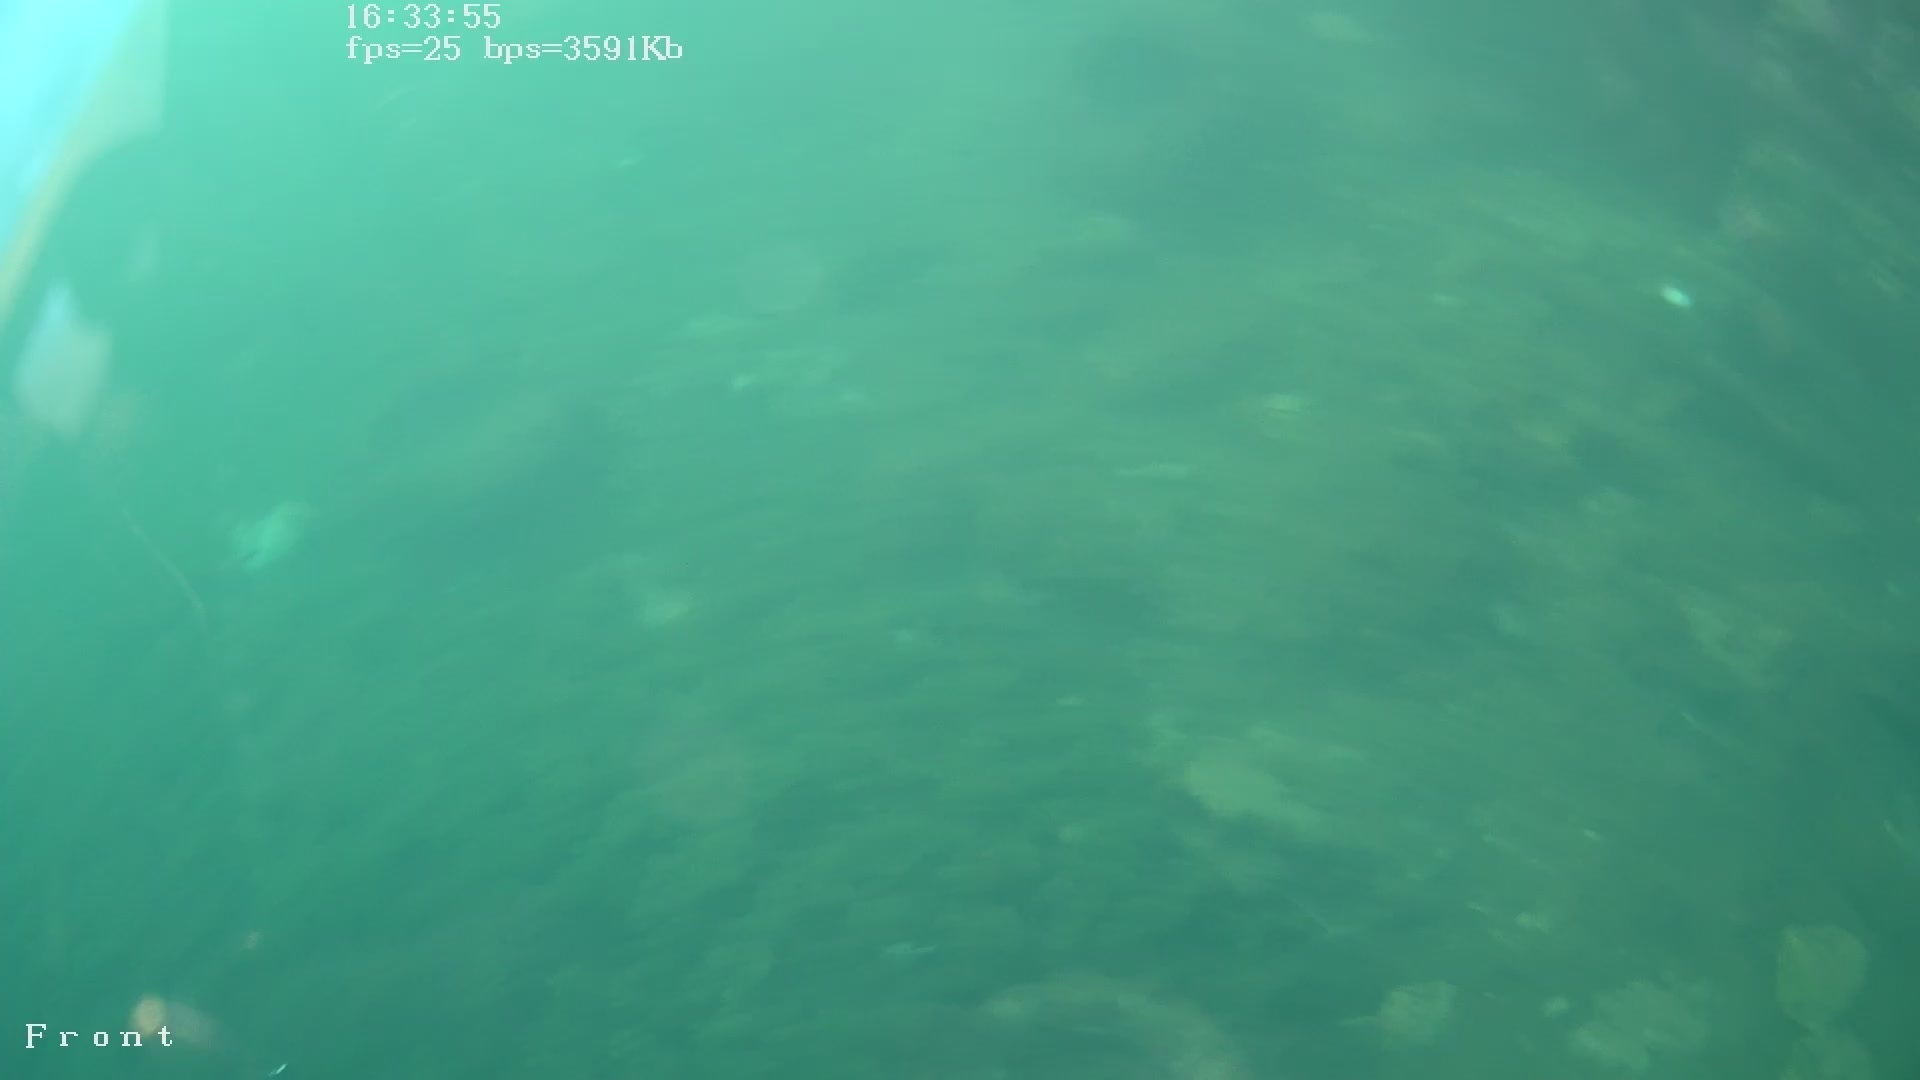

seaclear__2021_09_17_11_24_42_Front_10-49-18.jpg -> 0 detections


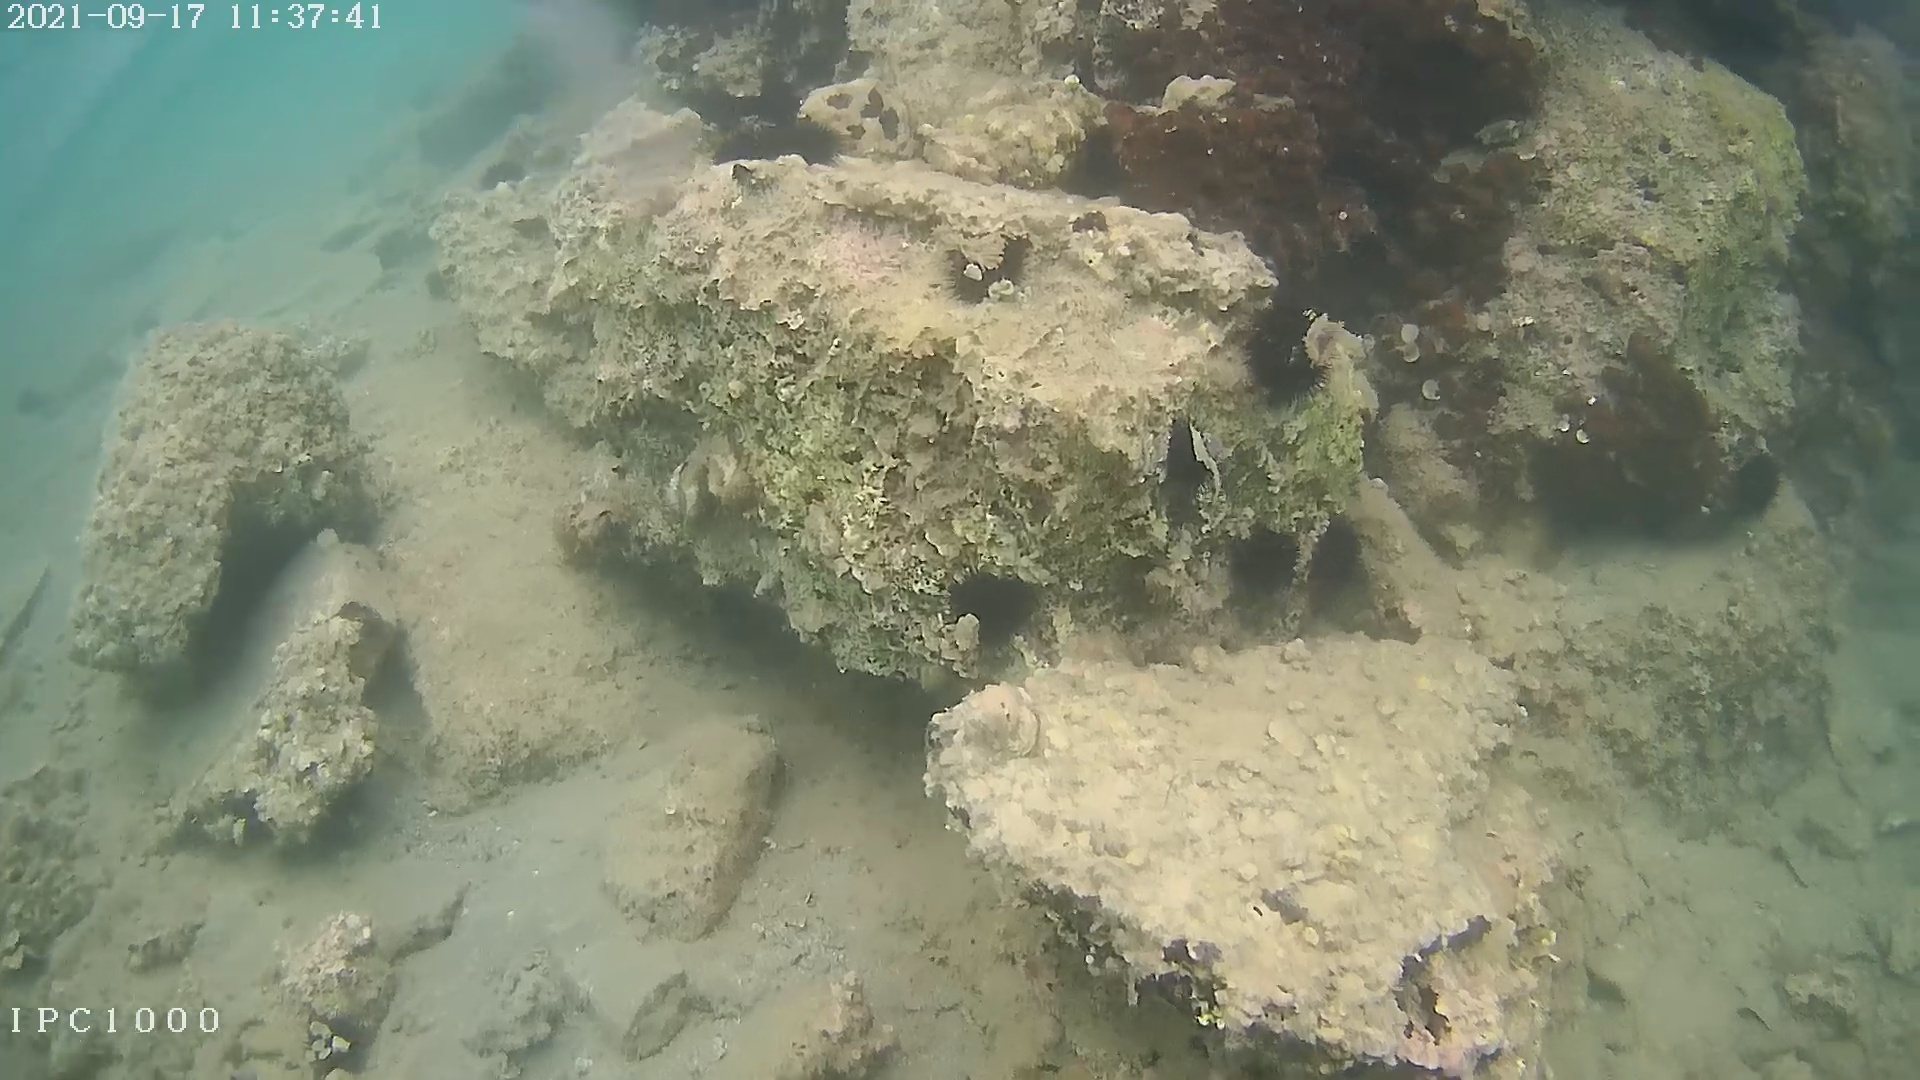

seaclear__Cam1_16_26_03_10_11_2020.mp4_00209.jpg -> 1 detections


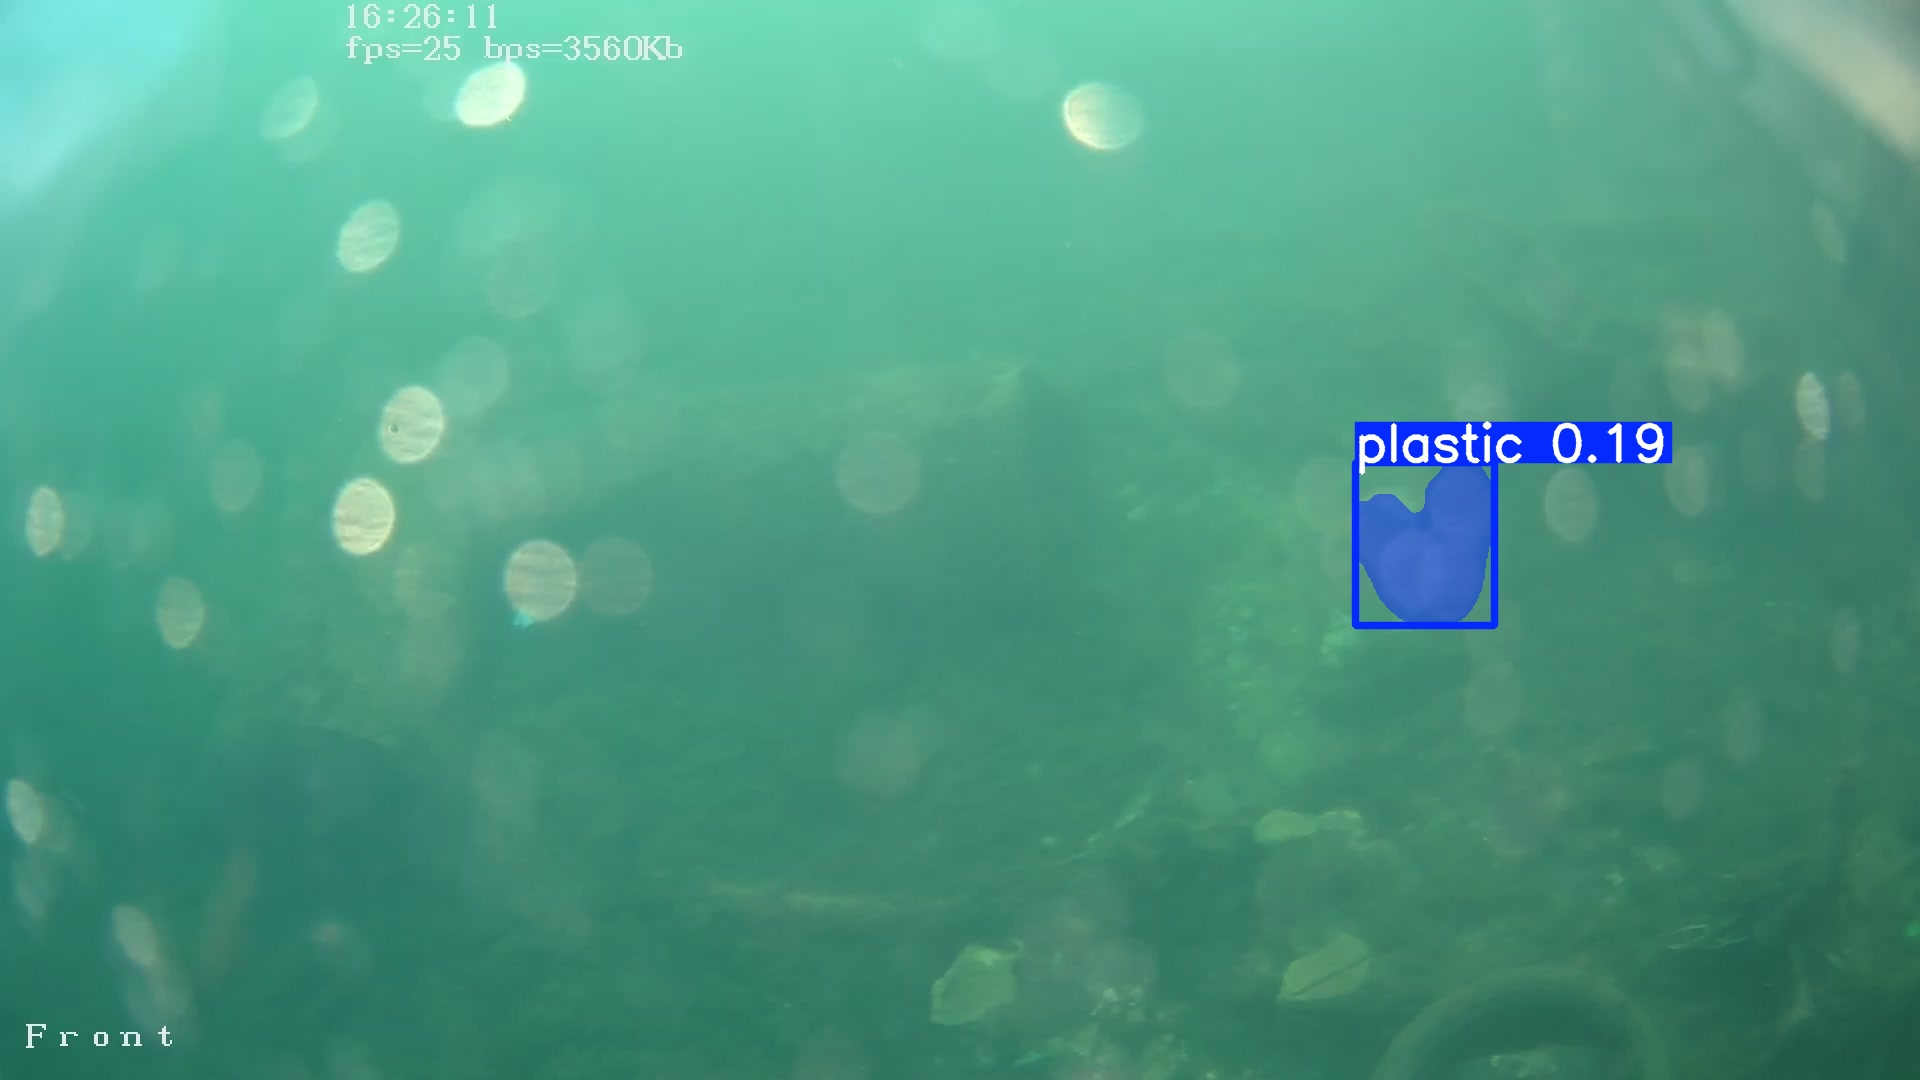

seaclear__4154.jpg -> 0 detections


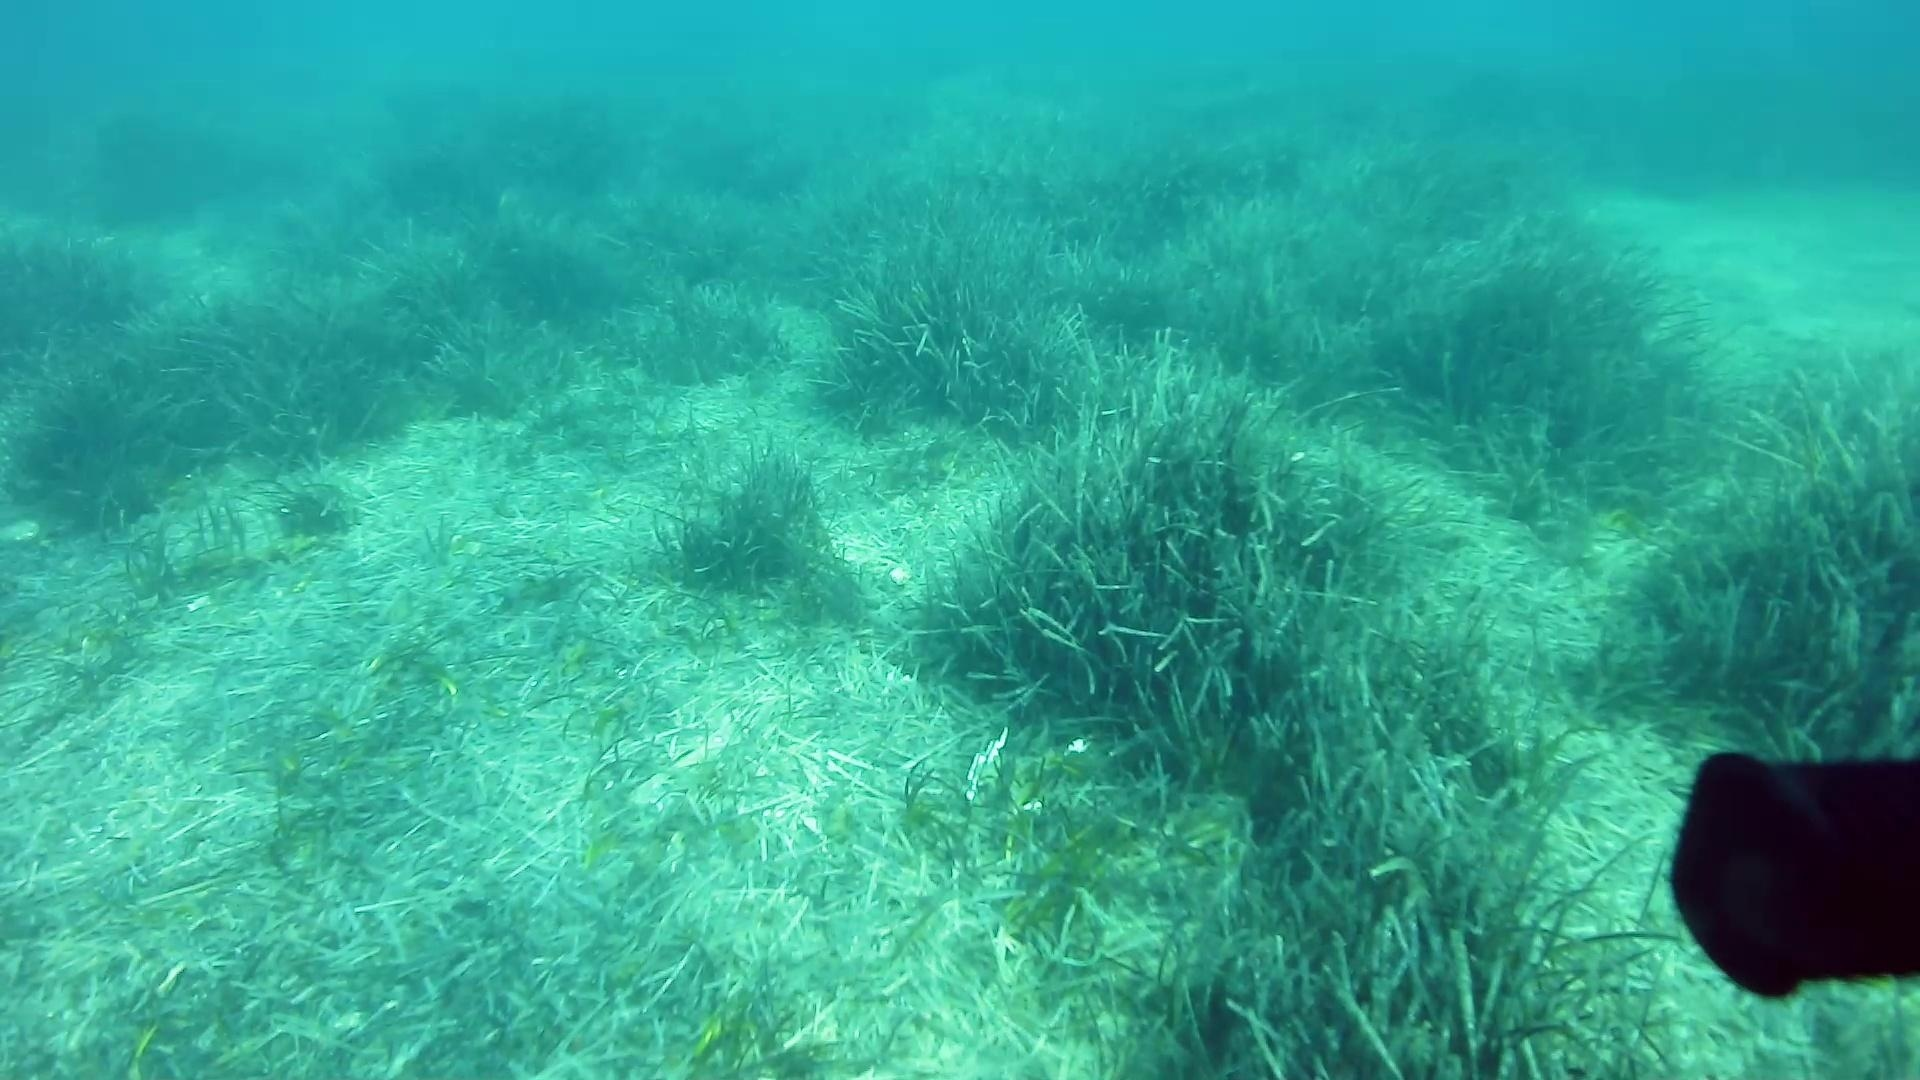

In [ ]:
# ── Cell 10b (fixed): what is the model actually predicting on SeaClear? ─────
import cv2, random
from pathlib import Path
from IPython.display import Image as IPImage, display

PRED = ROOT/'runs/pred'; PRED.mkdir(parents=True, exist_ok=True)
sc = [l.strip() for l in open(SPLITS/'seaclear_test.txt') if l.strip()]

for f in random.Random(0).sample(sc, 4):
    res = model.predict(f, imgsz=1280, conf=0.15, verbose=False)
    out = PRED/Path(f).name
    cv2.imwrite(str(out), res[0].plot())
    print(Path(f).name, '->', len(res[0].boxes), 'detections')
    display(IPImage(str(out), width=760))

In [ ]:
import shutil, subprocess
from pathlib import Path
ROOT  = Path('/content/nirmalsagar')
DRIVE = Path('/content/drive/MyDrive/nirmalsagar')
DRIVE.mkdir(parents=True, exist_ok=True)

# labels are the expensive artefact (Cell 4 took ~10 min); images are symlinks, skip them
subprocess.run(['tar','-czf', str(DRIVE/'labels_core3.tar.gz'),
                '-C', str(ROOT/'data/yolo'), 'labels'], check=True)
for d in ['splits','configs','paper']:
    shutil.copytree(ROOT/d, DRIVE/d, dirs_exist_ok=True)
subprocess.run(['tar','-czf', str(DRIVE/'eval_runs.tar.gz'),
                '-C', str(ROOT), 'runs/eval'], check=False)
print(sorted(p.name for p in DRIVE.iterdir()))

['configs', 'eval_runs.tar.gz', 'labels_core3.tar.gz', 'paper', 'raw', 'runs', 'splits']
